In [25]:
import pandas as pd
import numpy as np
import os 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [26]:
# Thoughts
# we shouldn't use paint quality anymore because we can't receive it anymore

In [27]:
# Load the data paths
data_dir = "../data/"

# Load the raw data into a pandas dataframe

train = pd.read_csv(os.path.join(data_dir, "train.csv"))

In [28]:
# Shapes (rows, columns)
print("Train shape:", train.shape)

# Column names
print("\nTrain columns:", train.columns.tolist())

# First 5 rows (peek at data)
display(train.head())

# Info (dtypes, non-null counts)
print("\nTrain info:")
print(train.info())

# Quick descriptive stats for numerics
train.describe().T


Train shape: (75973, 14)

Train columns: ['carID', 'Brand', 'model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage']


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0



Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB
None


,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


In [29]:
#check how values are missing for each category
print(train.isnull().sum())
#check the percentage of values missing for each category
print((train.isnull().sum() / len(train)) * 100)

# mpg and tax have a high missing percentage of around 10.4%

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64
carID              0.000000
Brand              2.002027
model              1.996762
year               1.962539
price              0.000000
transmission       2.003343
mileage            1.925684
fuelType           1.988864
tax               10.403696
mpg               10.432654
engineSize         1.995446
paintQuality%      2.005976
previousOwners     2.040198
hasDamage          2.037566
dtype: float64


In [30]:
# check numerical categories for numbers smaller than 0 and sum them
print((train.select_dtypes(include=['number']) < 0).sum())
# calculate the percentage
print(((train.select_dtypes(include=['number']) < 0).sum() / len(train)) * 100)
# data from 2020 -> newer cars should not exist
print("Cars with year greater then 2020: " + str((train['year'] > 2020).sum()))
# paint cannot be better quality then 100 percent
print("Cars with better quality then 100 percent: " + str((train['paintQuality%'] > 100).sum()))
# previous owners have to be an integer
print("Previous owner float numbers: " + str((train['previousOwners'] % 1 != 0).sum()))

carID               0
year                0
price               0
mileage           369
tax               378
mpg                36
engineSize         84
paintQuality%       0
previousOwners    371
hasDamage           0
dtype: int64
carID             0.000000
year              0.000000
price             0.000000
mileage           0.485699
tax               0.497545
mpg               0.047385
engineSize        0.110566
paintQuality%     0.000000
previousOwners    0.488331
hasDamage         0.000000
dtype: float64
Cars with year greater then 2020: 358
Cars with better quality then 100 percent: 367
Previous owner float numbers: 2284


In [31]:
# compare the mean negative values of a year to the mean positive value of a year 
# to see, if it is just a sign error
avg_mileage_by_year = train.assign(
    mileage_sign = np.where(train['mileage'] < 0, 'negative', 'positive')
).groupby(['year', 'mileage_sign'])['mileage'].mean().unstack()
print(avg_mileage_by_year)

mileage_sign      negative      positive
year                                    
1970.000000            NaN  25678.500000
1996.000000            NaN  50000.000000
1997.000000            NaN  62500.000000
1998.000000            NaN  67147.750000
1999.000000            NaN  61446.200000
2000.000000            NaN  66589.200000
2001.000000            NaN  65864.466667
2002.000000  -52618.457894  83498.181818
2003.000000            NaN  89402.894139
2004.000000  -58540.574478  93506.562500
2005.000000            NaN  92521.210736
2006.000000            NaN  87987.370968
2007.000000  -50755.210230  85368.866088
2008.000000  -42707.564215  90949.845161
2009.000000  -42707.564215  82456.742820
2009.816757            NaN  31150.891892
2010.000000  -48568.891663  81670.193966
2010.268635            NaN  24029.684211
2010.371546            NaN  18839.714286
2010.565009            NaN  23144.383813
2010.676968  -42650.453719  20625.012658
2010.746403            NaN  19030.912281
2011.000000  -47

In [32]:
# no sign error, so replace negative mileage values with the mean of cars build in the same year
for yr in train['year'].unique():
    year_mean = train.loc[(train['year']==yr) & (train['mileage']>=0), 'mileage'].mean()
    train.loc[(train['year']==yr) & (train['mileage']<0), 'mileage'] = year_mean

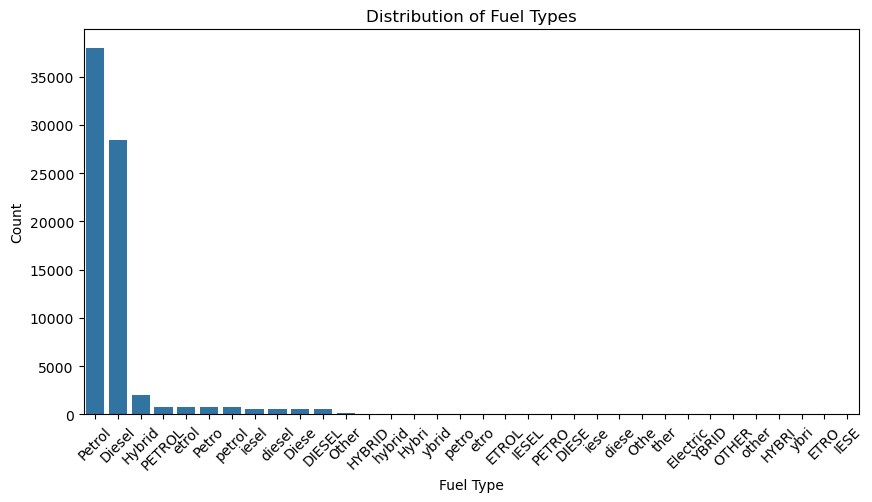

In [33]:
# check for error inputs in the fuel type data
plt.figure(figsize=(10,5))
sns.countplot(x='fuelType', data=train, order=train['fuelType'].value_counts().index)
plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

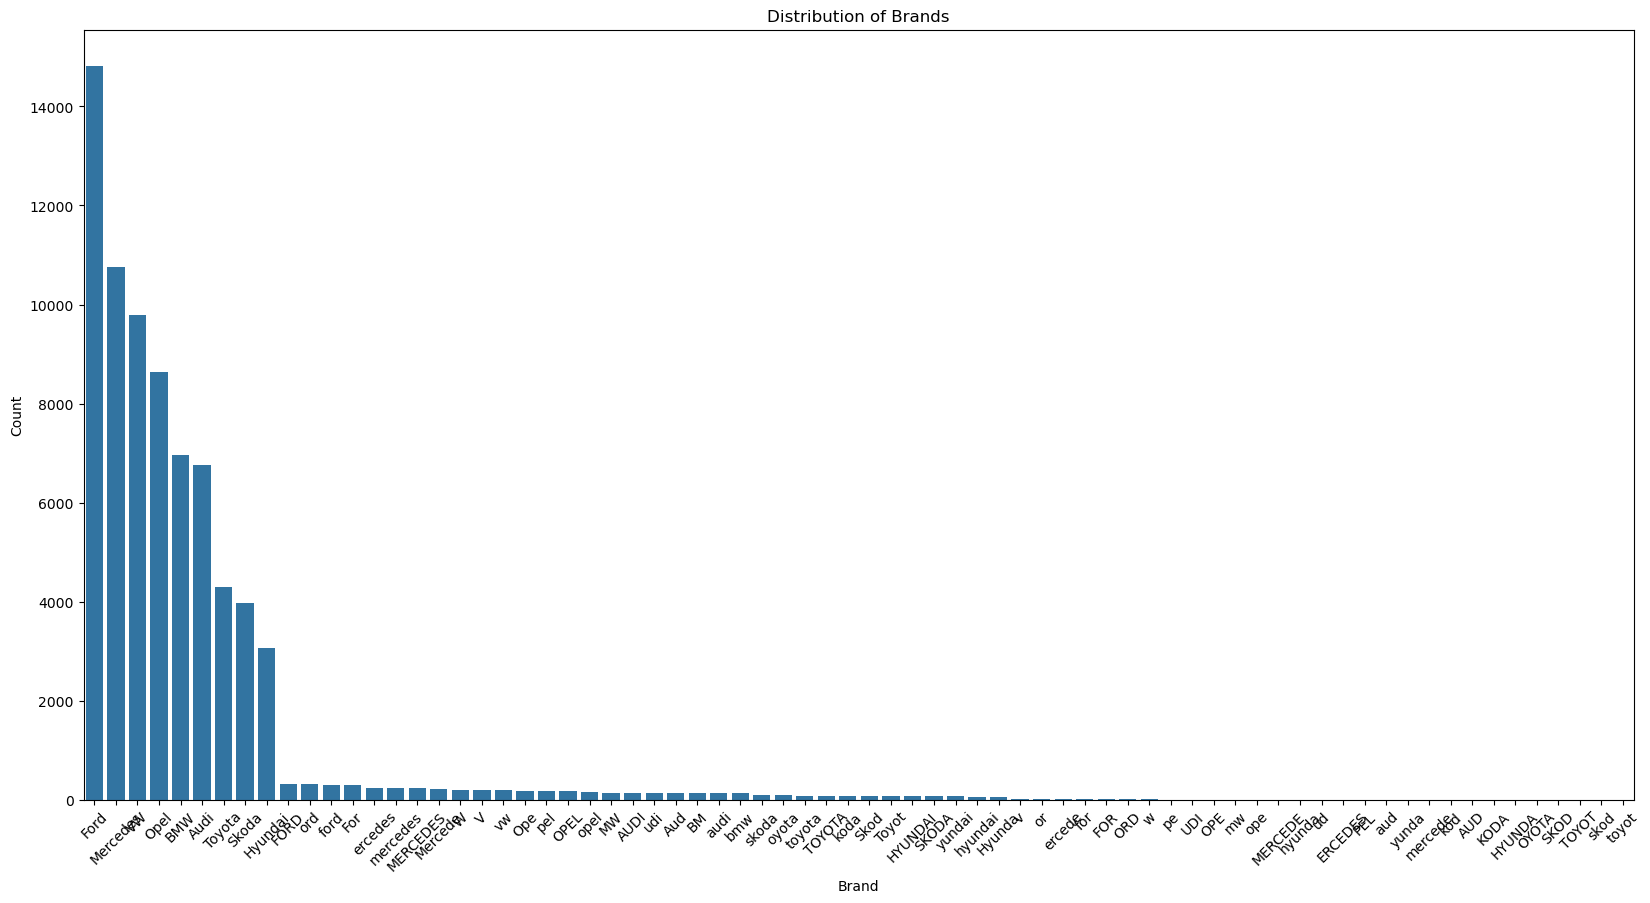

In [34]:
# check for error inputs in the Brand data
plt.figure(figsize=(20,10))
sns.countplot(x='Brand', data=train, order=train['Brand'].value_counts().index)
plt.title('Distribution of Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

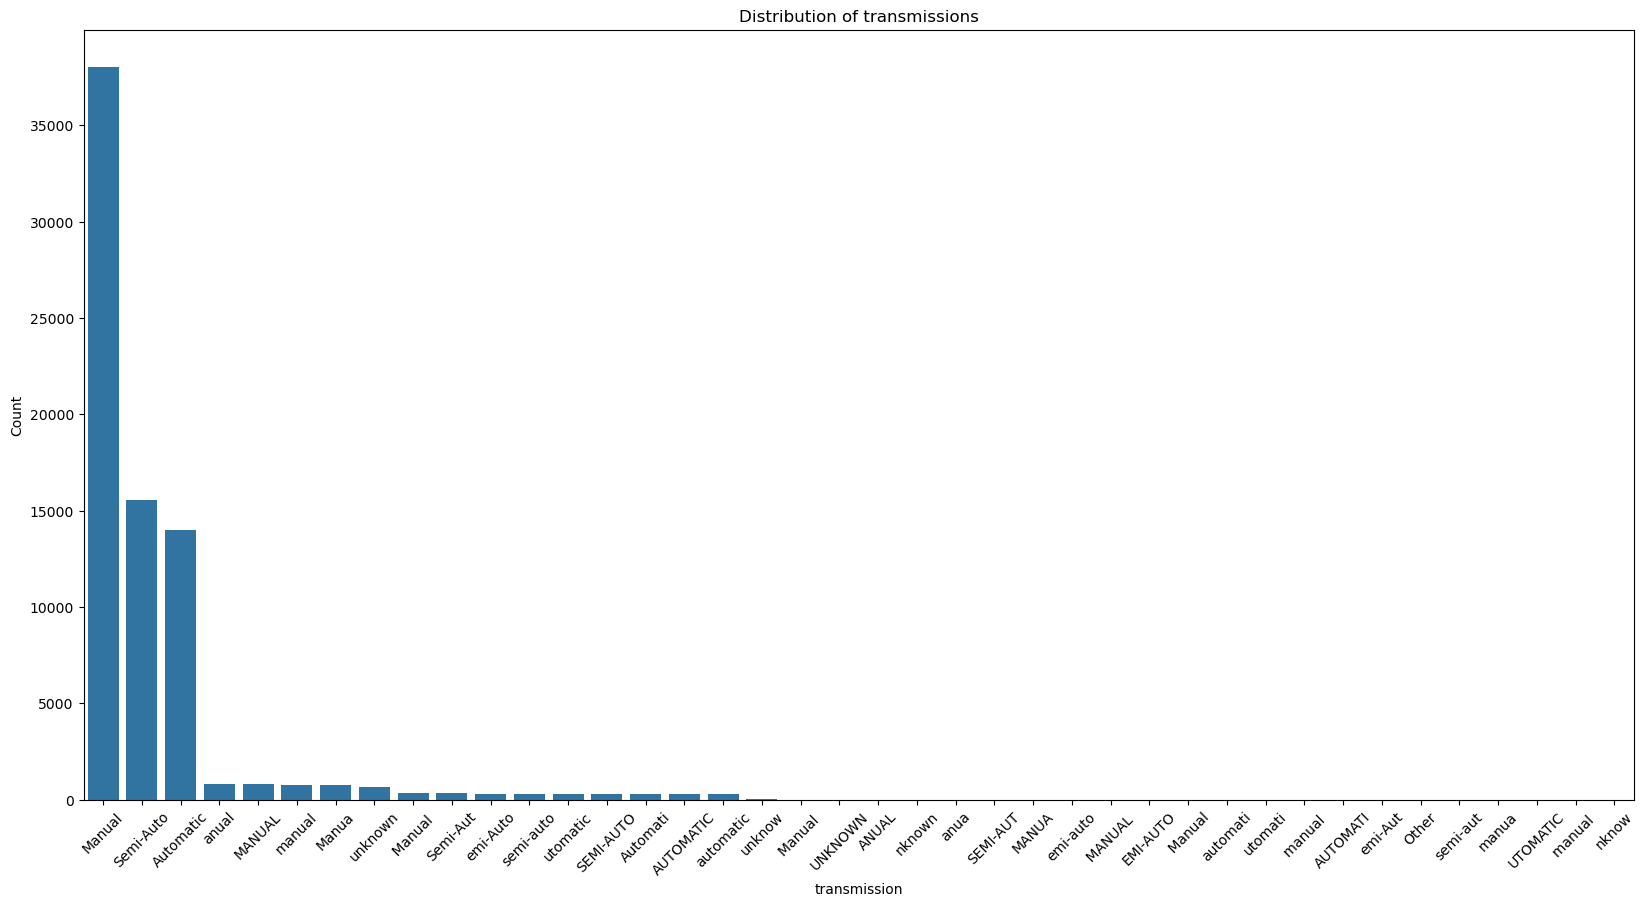

In [35]:
# check for error inputs in the transmission data
plt.figure(figsize=(20,10))
sns.countplot(x='transmission', data=train, order=train['transmission'].value_counts().index)
plt.title('Distribution of transmissions')
plt.xlabel('transmission')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [36]:
#correct the wrong data
train['fuelType'] = train['fuelType'].str.lower().str.strip()
train['fuelType'] = train['fuelType'].replace({
    'petrol': 'petrol',
    'petro': 'petrol',
    'petroL': 'petrol',
    'petro ': 'petrol',
    'petrl': 'petrol',
    'diesel': 'diesel',
    'diseel': 'diesel',
    'disel': 'diesel',
    'diese': 'diesel',
    'dise': 'diesel',
    'iesel': 'diesel',
    'iese': 'diesel',
    'etrol': 'petrol',
    'etro': 'petrol',
    'hybri': 'hybrid',
    'ybrid': 'hybrid',
    'ybri': 'hybrid',
    'hybrid': 'hybrid',
    'hyrbid': 'hybrid',
    'elec': 'electric',
    'electirc': 'electric',
    'electric': 'electric',
    'other': 'other',
    'othr': 'other',
    'othe': 'other',
    'ther': 'other',
    'oth': 'other'
})


# set category to lower cases and strip it
train['Brand'] = train['Brand'].str.lower().str.strip()

# replace common typos and variants
train['Brand'] = train['Brand'].replace({
    # Ford
    'frd': 'ford', 'for': 'ford', 'ord': 'ford', 'or': 'ford',
    # Mercedes
    'mercedes': 'mercedes', 'mercede': 'mercedes', 'mercedez': 'mercedes', 'ercede': 'mercedes',
    'merc': 'mercedes', 'mercedesbenz': 'mercedes', 'merceds': 'mercedes', 'ercedes': 'mercedes',
    # Opel
    'opel': 'opel', 'ope': 'opel', 'opl': 'opel', 'pel': 'opel', 'pe': 'opel',
    # BMW
    'bwm': 'bmw', 'bm': 'bmw', 'mw': 'bmw',
    # Audi
    'aud': 'audi', 'audii': 'audi', 'audy': 'audi', 'udi': 'audi', 'ud': 'audi',
    # Toyota
    'toyta': 'toyota', 'toyot': 'toyota', 't0yota': 'toyota', 'oyota': 'toyota',
    # Skoda
    'skod': 'skoda', 'škoda': 'skoda', 'koda': 'skoda', 'kod': 'skoda',
    # Hyundai
    'huyndai': 'hyundai', 'hyunday': 'hyundai', 'hyundia': 'hyundai', 'hyndai': 'hyundai', 
    'yundai': 'hyundai', 'hyunda': 'hyundai', 'yunda': 'hyundai',
    # Volkswagen
    'volkswagen': 'volkswagen', 'volkswagon': 'volkswagen', 'wolkswagen': 'volkswagen',
    'vw': 'volkswagen', 'v w': 'volkswagen', 'w': 'volkswagen', 'v': 'volkswagen',
    'wv': 'volkswagen', 'folkswagen': 'volkswagen',
    # Renault
    'reault': 'renault', 'renaul': 'renault',
    # Peugeot
    'peugot': 'peugeot', 'peugeot.': 'peugeot',
    # Citroen
    'citroën': 'citroen', 'citron': 'citroen',
    # Nissan
    'nisan': 'nissan', 'nissn': 'nissan',
    # Kia
    'kiaa': 'kia',
    # Fiat
    'fiat.': 'fiat',
})

# normalize casing and whitespace first
train['transmission'] = train['transmission'].str.lower().str.strip()


train['transmission'] = train['transmission'].replace({
    # Manual (seen: Manual, manual, MANUAL, anua)
    'Manual': 'manual',
    'manual': 'manual',
    'MANUAL': 'manual',
    'anua': 'manual',
    'anual': 'manual',
    'manua': 'manual',

    # Semi-Auto (seen: Semi-Auto, semi-auto, SEMI-AUTO, semi aut, emi-auto, emi-autc)
    'Semi-Auto': 'semi-auto',
    'semi-auto': 'semi-auto',
    'SEMI-AUTO': 'semi-auto',
    'semi aut': 'semi-auto',
    'emi-auto': 'semi-auto',
    'semi-aut': 'semi-auto',
    'emi-aut': 'semi-auto',
    'emi-autc': 'semi-auto',

    # Automatic (seen: Automatic, automatic, AUTOMATIC, utomatic, utomatl)
    'Automatic': 'automatic',
    'automatic': 'automatic',
    'AUTOMATIC': 'automatic',
    'utomatic': 'automatic',
    'utomatl': 'automatic',
    'utomati': 'automatic',
    'automati': 'automatic',
    # Unknown (seen: unknown, unknow, nknown, nknow, other)
    'unknown': 'unknown',
    'unknow': 'unknown',
    'nknown': 'unknown',
    'nknow': 'unknown',
    'other': 'unknown',
})

In [37]:
# Schritt 1: Gruppieren nach Marke und Damage-Status
avg_price_damage = (
    train.groupby(['Brand', 'hasDamage'], dropna=False)['price']
         .mean()
         .unstack()
)

# Schritt 2: Optional: sortieren nach Durchschnittspreis
avg_price_damage = avg_price_damage.sort_values(by=0, ascending=False)
avg_price_damage

hasDamage,0.0,NaN
Brand,,
mercedes,24507.692624,22760.086207
audi,22894.326875,22585.119205
bmw,22652.022947,22890.607595
NaN,16970.356183,19909.363636
volkswagen,16845.747125,17683.023810
skoda,14250.288325,13878.921348
hyundai,12808.900092,11912.079365
ford,12571.815987,13070.803077
toyota,12492.466180,11937.193878


In [38]:
print(train['price'].mean())
avg_price_per_brand = train.groupby('Brand')['price'].mean().sort_values(ascending=False)
print(avg_price_per_brand)

avg_price_per_fuel_type = train.groupby('fuelType')['price'].mean().sort_values(ascending=False)
print(avg_price_per_fuel_type)

avg_price_per_transmission = train.groupby('transmission')['price'].mean().sort_values(ascending=False)
print(avg_price_per_transmission)
# sorting the car brands by the average price to know how to fill the dummy variables
# sorting the car brands by the average price to know how to fill the dummy variables

16881.889552867466
Brand
mercedes      24472.962052
audi          22887.952765
bmw           22657.122565
volkswagen    16862.678093
skoda         14242.607251
hyundai       12791.963729
ford          12581.911909
toyota        12480.692774
opel          10367.619547
Name: price, dtype: float64
fuelType
hybrid      19276.771685
diesel      19181.155869
other       17202.077844
electric    15468.500000
petrol      15019.461281
Name: price, dtype: float64
transmission
semi-auto    24310.365161
automatic    21475.190126
unknown      16857.914980
manual       12193.656809
Name: price, dtype: float64


In [39]:
# Target Encoding
# Create a copy of the original DataFrame so we don't modify the original one
train_encoded = train.copy()

# Compute average price per brand (target encoding for 'Brand')
avg_price_per_brand = train_encoded.groupby('Brand')['price'].mean()
train_encoded['Brand_encoded'] = train_encoded['Brand'].map(avg_price_per_brand)

# Compute average price per fuel type (target encoding for 'fuelType')
avg_price_per_fuel = train_encoded.groupby('fuelType')['price'].mean()
train_encoded['fuelType_encoded'] = train_encoded['fuelType'].map(avg_price_per_fuel)

# Compute average price per fuel type (target encoding for 'fuelType')
avg_price_per_transmission = train_encoded.groupby('transmission')['price'].mean()
train_encoded['transmission_encoded'] = train_encoded['transmission'].map(avg_price_per_transmission)

# Drop the original categorical columns
train_encoded = train_encoded.drop(columns=['Brand', 'fuelType'])

#show the new data
train_encoded.head(20)

,carID,model,year,price,transmission,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,Brand_encoded,fuelType_encoded,transmission_encoded
0,69512,Golf,2016.0,22290,semi-auto,28421.000000,NaN,11.417268,2.0,63.0,4.000000,0.0,16862.678093,15019.461281,24310.365161
1,53000,Yaris,2019.0,13790,manual,4589.000000,145.0,47.900000,1.5,50.0,1.000000,0.0,12480.692774,15019.461281,12193.656809
2,6366,Q2,2019.0,24990,semi-auto,3624.000000,145.0,40.900000,1.5,56.0,4.000000,0.0,22887.952765,15019.461281,24310.365161
3,29021,FIESTA,2018.0,12500,manual,9102.000000,145.0,65.700000,1.0,50.0,-2.340306,0.0,12581.911909,15019.461281,12193.656809
4,10062,2 Series,2019.0,22995,manual,1000.000000,145.0,42.800000,1.5,97.0,3.000000,0.0,22657.122565,15019.461281,12193.656809
5,14704,3 Series,2014.0,8199,manual,101153.348285,30.0,65.700000,2.0,74.0,0.000000,0.0,22657.122565,19181.155869,12193.656809
6,6924,A3,2017.0,16089,manual,21396.000000,20.0,60.100000,1.4,75.0,4.000000,0.0,22887.952765,15019.461281,12193.656809
7,50783,Octavia,2017.0,7500,manual,116750.000000,145.0,68.900000,1.6,59.0,4.000000,0.0,14242.607251,19181.155869,12193.656809
8,67071,Passat,2017.0,15999,semi-auto,30339.000000,150.0,62.800000,2.0,85.0,4.000000,0.0,16862.678093,19181.155869,24310.365161
9,23348,Focus,2019.0,15300,manual,10700.000000,150.0,60.100000,1.0,35.0,1.000000,0.0,12581.911909,15019.461281,12193.656809


In [40]:
train_correlation = train_encoded.drop(columns=['carID'])
train_correlation['hasDamage'] = train_correlation['hasDamage'].fillna(1)

In [41]:
# Create a boolean mask of all valid rows
valid_rows = (
    (train['mileage'] >= 0) &
    (train['tax'] >= 0) &
    (train['mpg'] >= 0) &
    (train['engineSize'] >= 0) &
    (train['previousOwners'] >= 0) &
    (train['paintQuality%'] <= 100) &
    (train['year'] <= 2020) &
    ((train['previousOwners'] % 1) == 0)  # integer owners only
)

# Apply the mask to keep only valid rows
train_cleaned = train_correlation[valid_rows].copy()

In [42]:
# Spearman rank correlation for all numerical columns
rank_corr = train_cleaned.select_dtypes(include=[np.number]).corr(method='spearman')
# Define a function for highlighting strong correlations
def highlight_strong_corr(val):
    color = 'background-color: lightgreen' if abs(val) > 0.5 else ''
    return color

# Apply highlighting
rank_corr.style.map(highlight_strong_corr)

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,Brand_encoded,fuelType_encoded,transmission_encoded
year,1.000000,0.593311,-0.796249,0.322453,-0.317324,-0.025908,0.007577,0.002065,0.002234,0.081800,-0.096978,0.184973
price,0.593311,1.000000,-0.507994,0.315283,-0.386766,0.578505,0.006780,0.002132,0.001441,0.580329,0.293986,0.599434
mileage,-0.796249,-0.507994,1.000000,-0.259018,0.326735,0.094983,-0.002220,0.002479,-0.001707,-0.043102,0.189076,-0.155744
tax,0.322453,0.315283,-0.259018,1.000000,-0.558136,0.160915,0.006565,0.000176,0.006007,0.055341,-0.166118,0.171224
mpg,-0.317324,-0.386766,0.326735,-0.558136,1.000000,-0.200016,0.000514,0.002355,-0.005642,-0.065354,0.375332,-0.214105
engineSize,-0.025908,0.578505,0.094983,0.160915,-0.200016,1.000000,0.007369,0.004341,0.006088,0.507442,0.620101,0.502473
paintQuality%,0.007577,0.006780,-0.002220,0.006565,0.000514,0.007369,1.000000,-0.005181,0.001941,0.003582,0.000858,0.002003
previousOwners,0.002065,0.002132,0.002479,0.000176,0.002355,0.004341,-0.005181,1.000000,0.003628,-0.002594,0.004275,-0.006513
hasDamage,0.002234,0.001441,-0.001707,0.006007,-0.005642,0.006088,0.001941,0.003628,1.000000,0.003212,-0.001936,0.003818
Brand_encoded,0.081800,0.580329,-0.043102,0.055341,-0.065354,0.507442,0.003582,-0.002594,0.003212,1.000000,0.277501,0.496268


In [45]:
train_cleaned.groupby('hasDamage')['price'].agg(['mean', 'median', 'count', 'std'])

,mean,median,count,std
hasDamage,,,,
0.0,16816.723381,14495.0,57516,9891.836548
1.0,16766.166808,14550.0,1181,9384.993554


In [43]:
# feature engineering:
# age affects cars much more than the year: car_age in years
train['car_age'] = 2020 - train['year']
# it is important how efficent the motor is, 
train['efficiency_ratio'] = train['mpg'] / train['engineSize']
# calculate the average price of a brand and use it as well
brand_avg_price = train.groupby('Brand')['price'].mean()
train['brand_avg_price'] = train['Brand'].map(brand_avg_price)